In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset-620.csv')
df.head(5)

,category,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinine,gamma_glutamyl_transferase,protein
0,no_disease,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69
1,no_disease,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,no_disease,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,no_disease,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,no_disease,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   category                     615 non-null    object 
 1   age                          615 non-null    int64  
 2   sex                          615 non-null    object 
 3   albumin                      614 non-null    float64
 4   alkaline_phosphatase         597 non-null    float64
 5   alanine_aminotransferase     614 non-null    float64
 6   aspartate_aminotransferase   615 non-null    float64
 7   bilirubin                    615 non-null    float64
 8   cholinesterase               615 non-null    float64
 9   cholesterol                  605 non-null    float64
 10  creatinine                   615 non-null    float64
 11  gamma_glutamyl_transferase   615 non-null    float64
 12  protein                      615 non-null    object 
dtypes: float64(9), int64

In [4]:
df.describe()

,age,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinine,gamma_glutamyl_transferase
count,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000
mean,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171
std,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000
50%,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000
75%,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000
max,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000


In [5]:
df.isnull().sum()

category                        0
age                             0
sex                             0
albumin                         1
alkaline_phosphatase           18
alanine_aminotransferase        1
aspartate_aminotransferase      0
bilirubin                       0
cholinesterase                  0
cholesterol                    10
creatinine                      0
gamma_glutamyl_transferase      0
protein                         0
dtype: int64

In [6]:
df['category'].value_counts()

category
 no_disease        533
 cirrhosis          30
 hepatitis          24
 fibrosis           21
suspect_disease      7
Name: count, dtype: int64

In [7]:
#CALCULATING STATS FOR AGE FEATURE
Mean_age = df['age'].mean()
Median_age = df['age'].median()
Mode_Age = df['age'].mode()
IQR_Q1 = df['age'].quantile(0.25)
IQR_Q3 = df['age'].quantile(0.75)
IQR_Range = IQR_Q3 - IQR_Q1
print("Mean_Age:",Mean_age)
print("Median_Age:",Median_age)
print("Mode_Age:",Mode_Age)
print("IQR_Range_Age:",IQR_Range)

Mean_Age: 47.40813008130081
Median_Age: 47.0
Mode_Age: 0    46
Name: age, dtype: int64
IQR_Range_Age: 15.0


In [8]:
#From the above stats the mean is closer to the median value which indicates the age feature is approximately symmetric with few outliers.

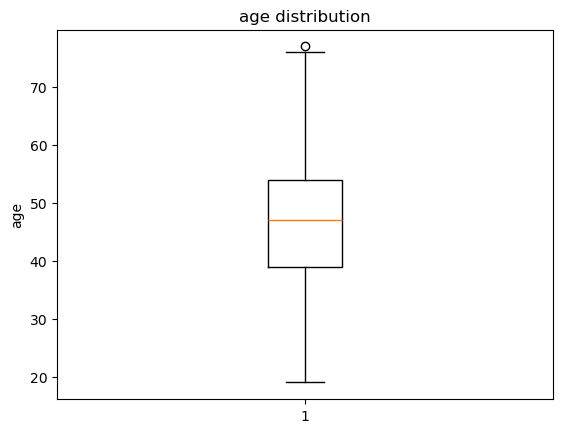

In [9]:
plt.boxplot(df["age"])
plt.ylabel("age")
plt.title("age distribution")
plt.show()

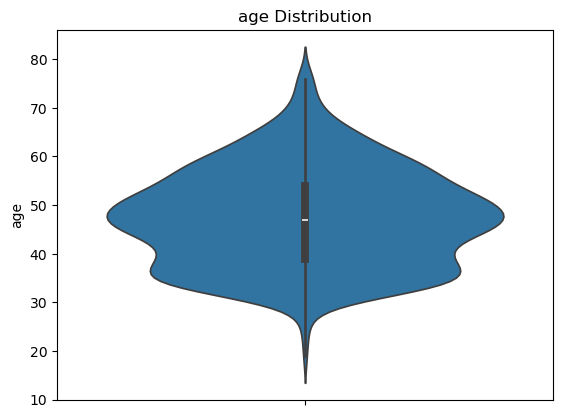

In [10]:
sns.violinplot(y=df["age"])
plt.title("age Distribution")
plt.show()

In [11]:
#From the above box and violin plots we can observe that there aren't many outliers and the age data is densely distributed between 35-50. Since there is
#not many outliers, we are keeping them as is for better training of the model.

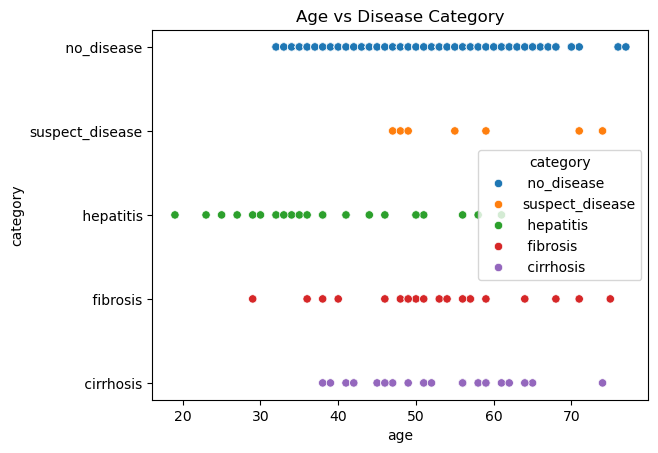

In [12]:
sns.scatterplot(x='age',y='category',hue='category',data=df)
plt.title("Age vs Disease Category")
plt.show()

In [13]:
#The scatter plot shows liver disease occurs across different age groups. Although certain diseases like fibrosis and cirrhosis appears more frequently 
#in the middle and old aged people. Further analysis is required.

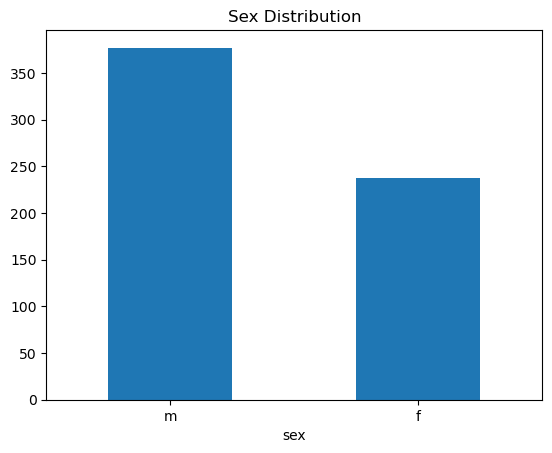

In [14]:
df["sex"].value_counts().plot(kind="bar")
plt.title("Sex Distribution")
plt.xticks(rotation=0)
plt.show()

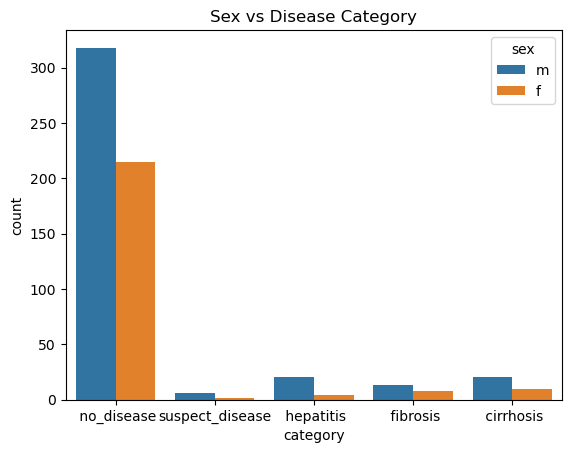

In [15]:
sns.countplot(x='category',hue='sex',data=df)
plt.title('Sex vs Disease Category')
plt.show()

In [16]:
#From the above plot it can be seen that disease like cirrhosis fibrosis and hepatitis are more among males than females.
#The sex distribution shows there are more males than females in the dataset.

In [17]:
#CALCULATING STATS FOR ALBUMIN FEATURE
Mean_albumin = df['albumin'].mean()
Median_albumin = df['albumin'].median()
Mode_albumin = df['albumin'].mode()
IQR_Q1 = df['albumin'].quantile(0.25)
IQR_Q3 = df['albumin'].quantile(0.75)
IQR_Range_Albumin = IQR_Q3 - IQR_Q1
print("Mean_albumin:",Mean_albumin)
print("Median_albumin:",Median_albumin)
print("Mode_albumin:",Mode_albumin)
print("IQR_Range_albumin:",IQR_Range_Albumin)

Mean_albumin: 41.62019543973941
Median_albumin: 41.95
Mode_albumin: 0    39.0
Name: albumin, dtype: float64
IQR_Range_albumin: 6.400000000000006


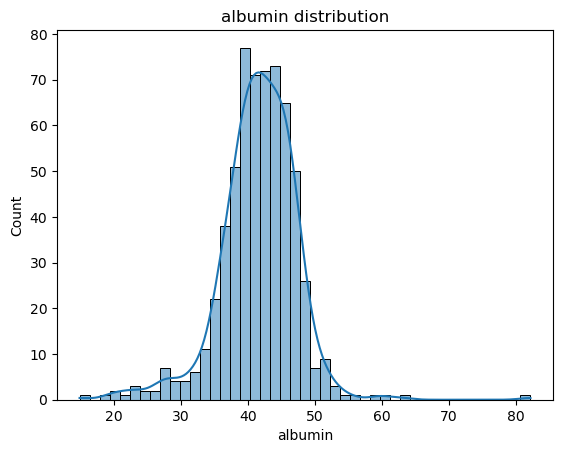

In [18]:
sns.histplot(x='albumin',data=df,kde=True)
plt.title('albumin distribution')
plt.show()

In [19]:
#The above histogram shows albummin appears close to normal with few extreme values. Since albumin is a protein produced by liver the values above 55
#are mostly rare hence we are flagging them as high albumin. The lower extreme values must be kept as is since they are clinically significant to identify
#liver or kidney disease.

In [20]:
df["albumin_high_outlier"] = df["albumin"] > 55

In [21]:
df.loc[df["albumin"] > 55, "albumin"] = Median_albumin

In [22]:
df["albumin"].fillna(Median_albumin)

0      38.5
1      38.5
2      46.9
3      43.2
4      39.2
       ... 
610    32.0
611    24.0
612    29.0
613    33.0
614    36.0
Name: albumin, Length: 615, dtype: float64

In [23]:
df['albumin'].isnull().sum()

np.int64(1)

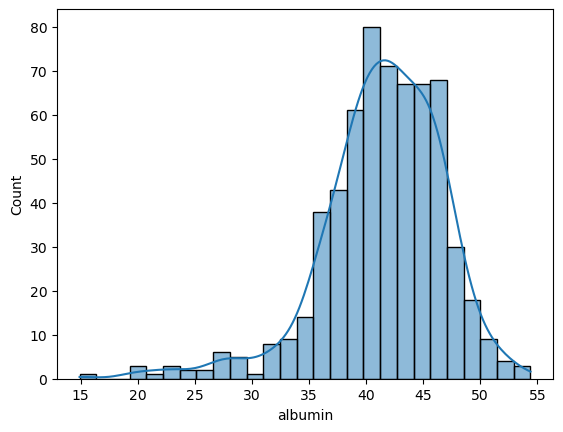

In [24]:
sns.histplot(df["albumin"], kde=True)
plt.show()

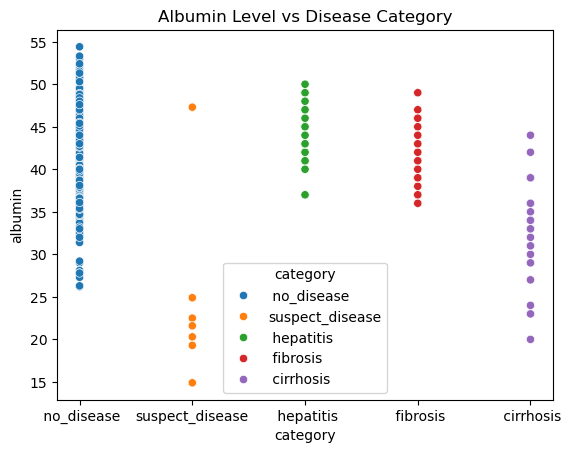

In [25]:
sns.scatterplot(x='category',y='albumin',hue='category',data=df)
plt.title('Albumin Level vs Disease Category')
plt.show()

In [26]:
#From the plot, it can be observed that conditions such as hepatitis and fibrosis occur even within the normal albumin range. 
#Therefore, normal albumin levels alone do not necessarily indicate the absence of liver disease.

In [27]:
#CALCULATING STATS FOR ALKALINE PHOSPHATASE FEATURE
Mean_alkaline_phosphatase = df['alkaline_phosphatase'].mean()
Median_alkaline_phosphatase = df['alkaline_phosphatase'].median()
Mode_alkaline_phosphatase = df['alkaline_phosphatase'].mode()
IQR_Q1 = df['alkaline_phosphatase'].quantile(0.25)
IQR_Q3 = df['alkaline_phosphatase'].quantile(0.75)
IQR_Range_alkaline_phosphatase = IQR_Q3 - IQR_Q1
print("Mean_alkaline_phosphatase:",Mean_alkaline_phosphatase)
print("Median_alkaline_phosphatase:",Median_alkaline_phosphatase)
print("Mode_alkaline_phosphatase:",Mode_alkaline_phosphatase)
print("IQR_Range_alkaline_phosphatase:",IQR_Range_alkaline_phosphatase)

Mean_alkaline_phosphatase: 68.28391959798995
Median_alkaline_phosphatase: 66.2
Mode_alkaline_phosphatase: 0    52.5
1    61.2
Name: alkaline_phosphatase, dtype: float64
IQR_Range_alkaline_phosphatase: 27.599999999999994


In [28]:
#The stats calcuation shows that alkaline phosphatase feature is slightly right skewed indicated by the Mean which is greater than the median.
df['alkaline_phosphatase'].isnull().sum()

np.int64(18)

In [29]:
df['alkaline_phosphatase'] = df['alkaline_phosphatase'].fillna(Median_alkaline_phosphatase)

In [30]:
df['alkaline_phosphatase'].isnull().sum()

np.int64(0)

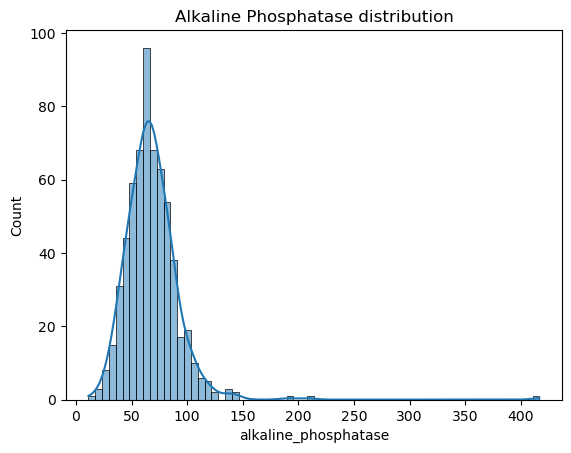

In [31]:
sns.histplot(df['alkaline_phosphatase'],kde=True)
plt.title('Alkaline Phosphatase distribution')
plt.show()

<Axes: >

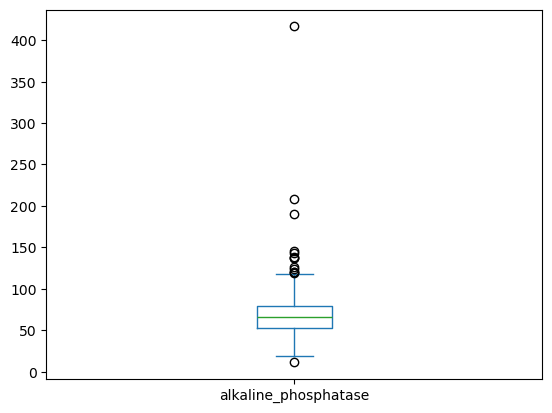

In [32]:
df['alkaline_phosphatase'].plot(kind='box')

In [33]:
#The box plot shows extreme values which are common in alkaline test and it is an indicator of liver or kidney disease. Hence keeping the values as is
#for better model training.

In [34]:
df["ALP_log"] = np.log1p(df["alkaline_phosphatase"])

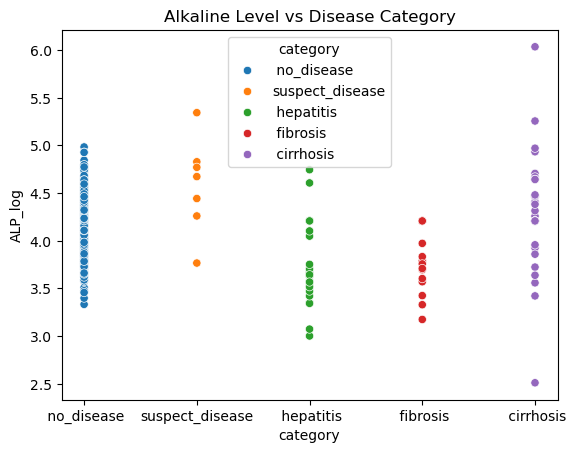

In [35]:
sns.scatterplot(x='category',y='ALP_log',hue='category',data=df)
plt.title('Alkaline Level vs Disease Category')
plt.show()

In [36]:
#The Alkaline_phosphatase is an enzyme that is found in liver.
#From the plot, it can be observed that conditions such as hepatitis cirrhosis and fibrosis occur even within the normal alkaline range. 
#Therefore, normal alkaline levels alone do not necessarily indicate the absence of liver disease.

In [37]:
#CALCULATING STATS FOR ALANINE_AMINOTRANSFERASE
df['alanine_aminotransferase'].isnull().sum()

np.int64(1)

In [38]:
#CALCULATING STATS FOR ALKALINE PHOSPHATASE FEATURE
Mean_alanine_aminotransferase = df['alanine_aminotransferase'].mean()
Median_alanine_aminotransferase = df['alanine_aminotransferase'].median()
Mode_alanine_aminotransferase = df['alanine_aminotransferase'].mode()
IQR_Q1 = df['alanine_aminotransferase'].quantile(0.25)
IQR_Q3 = df['alanine_aminotransferase'].quantile(0.75)
IQR_Range_alanine_aminotransferase = IQR_Q3 - IQR_Q1
print("Mean_alanine_aminotransferase:",Mean_alanine_aminotransferase)
print("Median_alanine_aminotransferase:",Median_alanine_aminotransferase)
print("Mode_alanine_aminotransferase:",Mode_alanine_aminotransferase)
print("IQR_Range_alanine_aminotransferase:",IQR_Range_alanine_aminotransferase)

Mean_alanine_aminotransferase: 28.450814332247557
Median_alanine_aminotransferase: 23.0
Mode_alanine_aminotransferase: 0    16.6
Name: alanine_aminotransferase, dtype: float64
IQR_Range_alanine_aminotransferase: 16.675000000000004


In [39]:
#Based on the above stats, it is clear that the alanine_aminotransferase feature is right skewed indicated by the fact that mean is higher than the median.

In [40]:
df['alanine_aminotransferase']=df['alanine_aminotransferase'].fillna(Median_alanine_aminotransferase)

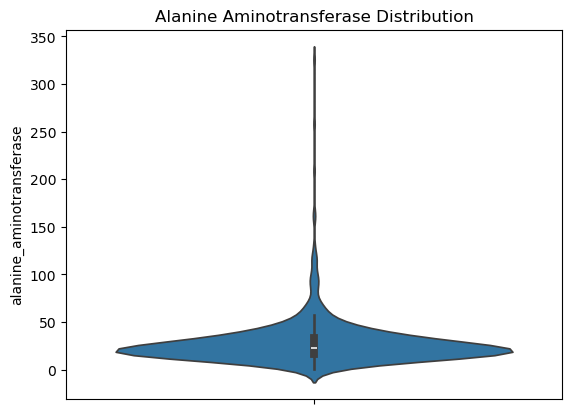

In [41]:
sns.violinplot(y='alanine_aminotransferase',data=df)
plt.title('Alanine Aminotransferase Distribution')
plt.show()

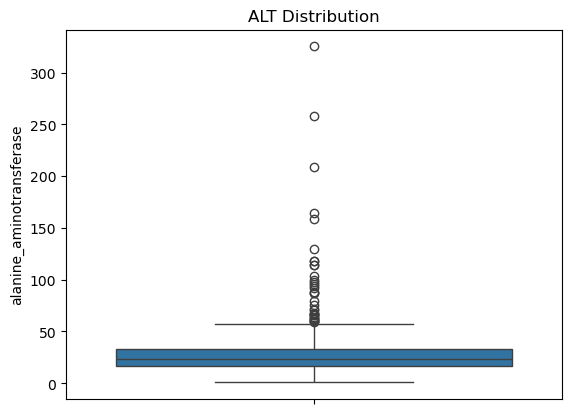

In [42]:
sns.boxplot(y='alanine_aminotransferase',data=df)
plt.title('ALT Distribution')
plt.show()

In [43]:
#The Alanine_aminotransferase is an enzyme released by liver when it is irritated.
#The above plots show the ALT is highly extreme, but they cannot be considered as outliers since these are clinically important indicators of Liver disease.
#The values are extreme which could affect the model, hence performing log transformation and keeping the outliers as is.

In [44]:
df["ALT_log"] = np.log1p(df["alanine_aminotransferase"])

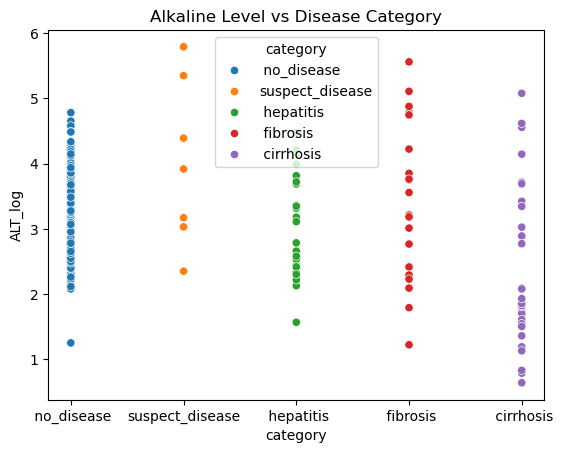

In [45]:
sns.scatterplot(x='category',y='ALT_log',hue='category',data=df)
plt.title('Alkaline Level vs Disease Category')
plt.show()

In [46]:
#From the plot, it can be observed that conditions such as hepatitis cirrhosis and fibrosis occur even within the normal alanine range. 
#Therefore, normal alanine levels alone do not necessarily indicate the absence of liver disease.

In [47]:
df['aspartate_aminotransferase'].isnull().sum()

np.int64(0)

In [48]:
#STATS CALCULATION FOR ASPARTATE_AMINOTRANSFERASE
Mean_aspartate_aminotransferase = df['aspartate_aminotransferase'].mean()
Median_aspartate_aminotransferase = df['aspartate_aminotransferase'].median()
Mode_aspartate_aminotransferase = df['aspartate_aminotransferase'].mode()
IQR_Q1 = df['aspartate_aminotransferase'].quantile(0.25)
IQR_Q3 = df['aspartate_aminotransferase'].quantile(0.75)
IQR_Range_aspartate_aminotransferase = IQR_Q3 - IQR_Q1
print("Mean_aspartate_aminotransferase:",Mean_aspartate_aminotransferase)
print("Median_aspartate_aminotransferase:",Median_aspartate_aminotransferase)
print("Mode_aspartate_aminotransferase:",Mode_aspartate_aminotransferase)
print("IQR_Range_aspartate_aminotransferase:",IQR_Range_aspartate_aminotransferase)

Mean_aspartate_aminotransferase: 34.78634146341463
Median_aspartate_aminotransferase: 25.9
Mode_aspartate_aminotransferase: 0    22.0
1    23.9
2    24.3
Name: aspartate_aminotransferase, dtype: float64
IQR_Range_aspartate_aminotransferase: 11.299999999999997


In [49]:
#Based on the above stats, it is clear that the aspartate_aminotransferase feature is right skewed indicated by the fact that mean is higher than the median.

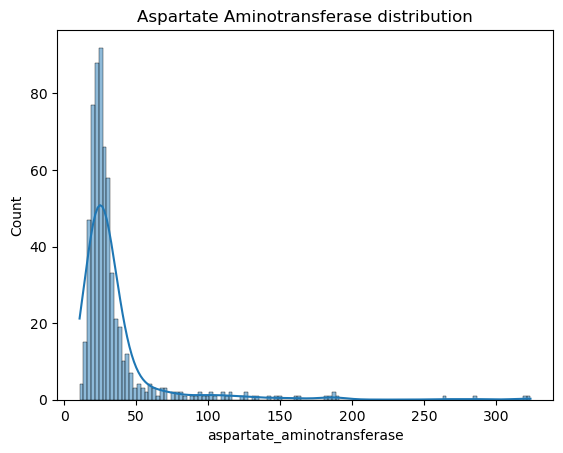

In [50]:
sns.histplot(df['aspartate_aminotransferase'],kde=True)
plt.title('Aspartate Aminotransferase distribution')
plt.show()

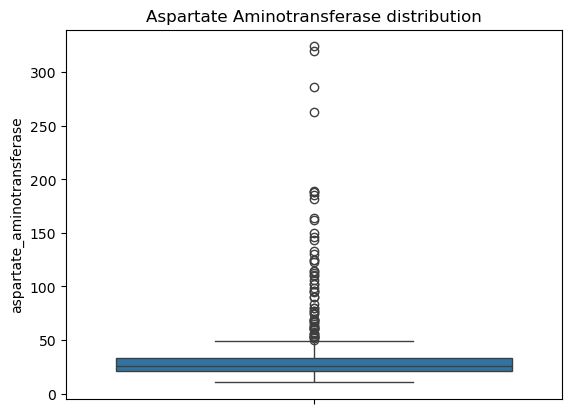

In [51]:
sns.boxplot(df['aspartate_aminotransferase'])
plt.title('Aspartate Aminotransferase distribution')
plt.show()

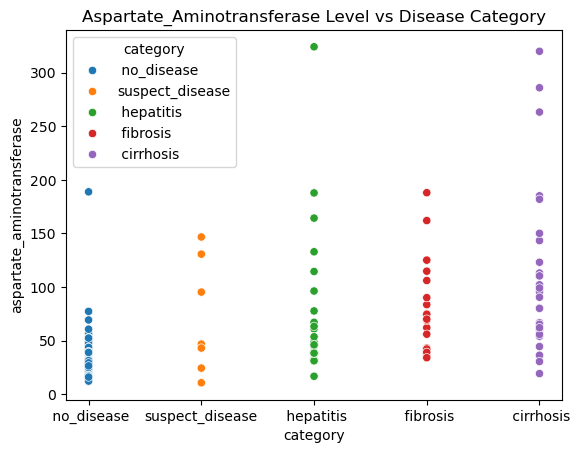

In [52]:
sns.scatterplot(x='category',y='aspartate_aminotransferase',hue='category',data=df)
plt.title('Aspartate_Aminotransferase Level vs Disease Category')
plt.show()

In [53]:
#Aspartate Aminotransferase is an enzyme involved in amino acid metabolism. This is not specific to liver but plays an important role identifying liver disease.
#The box and hist plot shows extreme high values. They cannot be considered os outliers as those values might indicate liver disease.
#The above comparison shows that people with normal ASP level are also prone to liver disease such as cirrhosis and fibrosis.

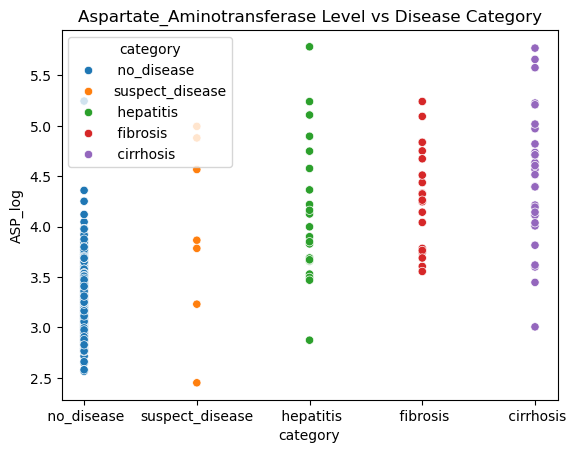

In [54]:
df['ASP_log'] = np.log1p(df['aspartate_aminotransferase'])
sns.scatterplot(x='category',y='ASP_log',hue='category',data=df)
plt.title('Aspartate_Aminotransferase Level vs Disease Category')
plt.show()

In [55]:
df['bilirubin'].isnull().sum()

np.int64(0)

In [56]:
#STATS CALCULATION FOR BILIRUBIN
Mean_bilirubin = df['bilirubin'].mean()
Median_bilirubin = df['bilirubin'].median()
Mode_bilirubin = df['bilirubin'].mode()
IQR_Q1 = df['bilirubin'].quantile(0.25)
IQR_Q3 = df['bilirubin'].quantile(0.75)
IQR_Range_bilirubin = IQR_Q3 - IQR_Q1
print("Mean_bilirubin:",Mean_bilirubin)
print("Median_bilirubin:",Median_bilirubin)
print("Mode_bilirubin:",Mode_bilirubin)
print("IQR_Range_bilirubin:",IQR_Range_bilirubin)

Mean_bilirubin: 11.396747967479675
Median_bilirubin: 7.3
Mode_bilirubin: 0    6.0
Name: bilirubin, dtype: float64
IQR_Range_bilirubin: 5.8999999999999995


In [57]:
#The above stats calculation shows that the bilirubin data is right skewed indicated by the fact that mean is greater than the median.

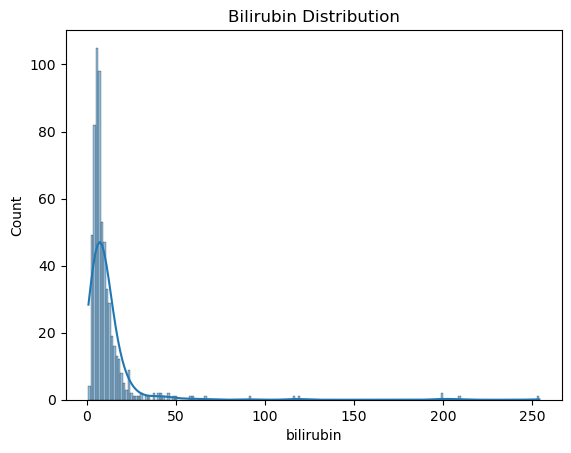

In [58]:
sns.histplot(df['bilirubin'],kde=True)
plt.title('Bilirubin Distribution')
plt.show()

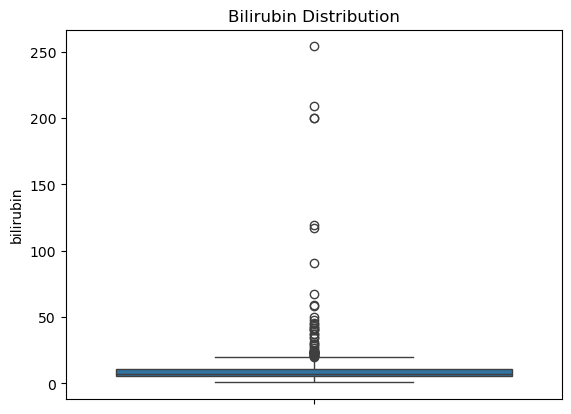

In [59]:
sns.boxplot(y='bilirubin',data=df)
plt.title('Bilirubin Distribution')
plt.show()

In [60]:
#The box plot and histogram shows bilirubin feature has exterme values. Bilirubin is a pigment which liver will take from blood process it and send it out
#through bile. The high bilirubin levels are the indicators of liver disease such as cirrhosis etc.., Hence keeping the value as is for better ML model training.

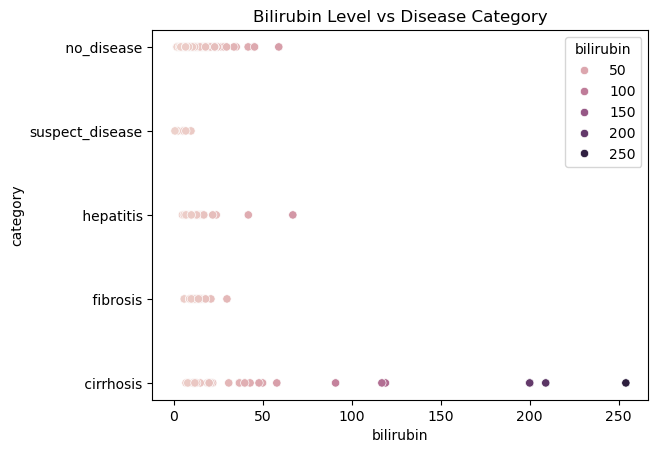

In [61]:
sns.scatterplot(x='bilirubin',y='category',hue='bilirubin',data=df)
plt.title('Bilirubin Level vs Disease Category')
plt.show()

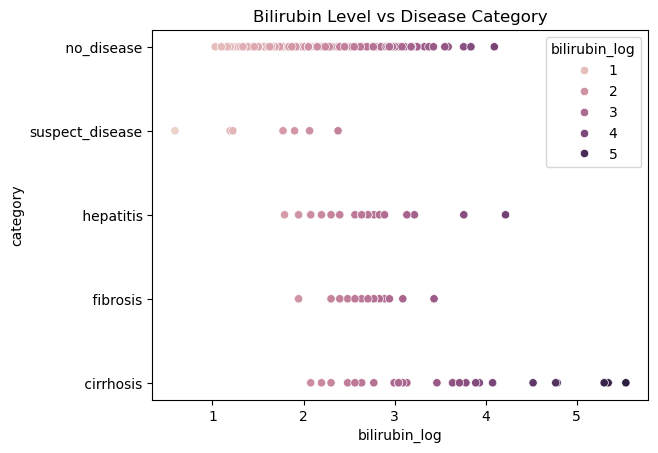

In [62]:
df['bilirubin_log'] = np.log1p(df['bilirubin'])
sns.scatterplot(x='bilirubin_log',y='category',hue='bilirubin_log',data=df)
plt.title('Bilirubin Level vs Disease Category')
plt.show()

In [63]:
df['cholinesterase'].isnull().sum()

np.int64(0)

In [64]:
#STATS CALCULATION FOR CHOLINSTERASE
Mean_cholinesterase = df['cholinesterase'].mean()
Median_cholinesterase = df['cholinesterase'].median()
Mode_cholinesterase = df['cholinesterase'].mode()
IQR_Q1 = df['cholinesterase'].quantile(0.25)
IQR_Q3 = df['cholinesterase'].quantile(0.75)
IQR_Range_cholinesterase = IQR_Q3 - IQR_Q1
print("Mean_cholinesterase:",Mean_cholinesterase)
print("Median_cholinesterase:",Median_cholinesterase)
print("Mode_cholinesterase:",Mode_cholinesterase)
print("IQR_Range_cholinesterase:",IQR_Range_cholinesterase)

Mean_cholinesterase: 8.196634146341465
Median_cholinesterase: 8.26
Mode_cholinesterase: 0    7.52
Name: cholinesterase, dtype: float64
IQR_Range_cholinesterase: 2.6549999999999994


In [65]:
#From the above stats it can be seen that in the cholinesterase data no strong skewness observed and there is liitle skewness in the data since the mean is almost
#equal to the median.

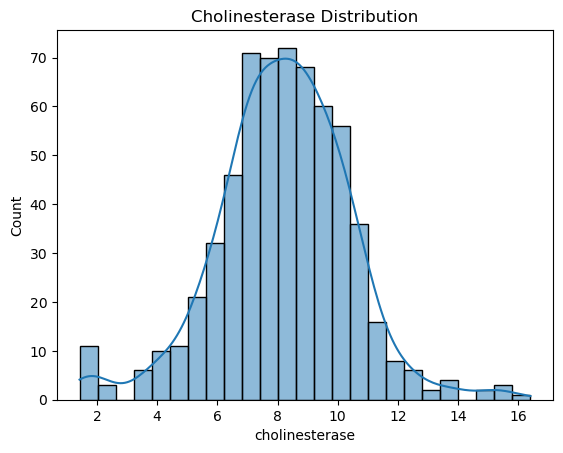

In [66]:
sns.histplot(df['cholinesterase'],kde=True)
plt.title('Cholinesterase Distribution')
plt.show()

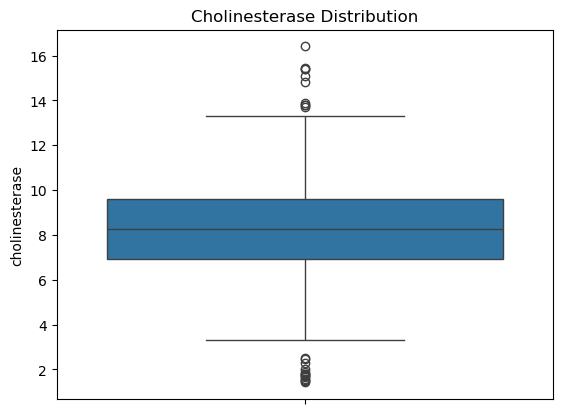

In [67]:
sns.boxplot(df['cholinesterase'])
plt.title('Cholinesterase Distribution')
plt.show()

In [68]:
#Cholinesterase means a serum cholinesterase which is produced by the liver and it is one of the indicators of liver disease.
#The above plots show that the cholinesterase feature has no extreme outliers and is normally distributed. Leaving the value as for better prediction of liver disease.

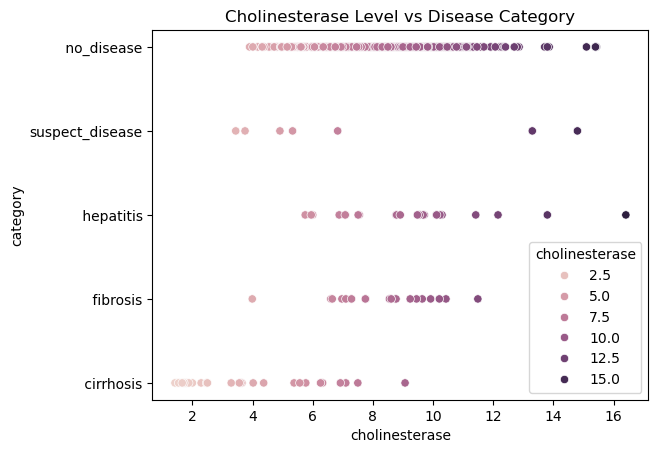

In [69]:
sns.scatterplot(x='cholinesterase',y='category',hue='cholinesterase',data=df)
plt.title('Cholinesterase Level vs Disease Category')
plt.show()

In [70]:
#The above comparison shows that people with normal cholinesterase level are prone to be affected by liver disease.
#The lower values often indicate the presence of liver disease such as cirrhosis.

In [71]:
#STATS CALCULATION FOR CHOLESTROL
Mean_cholesterol = df['cholesterol'].mean()
Median_cholesterol = df['cholesterol'].median()
Mode_cholesterol = df['cholesterol'].mode()
IQR_Q1 = df['cholesterol'].quantile(0.25)
IQR_Q3 = df['cholesterol'].quantile(0.75)
IQR_Range_cholesterol = IQR_Q3 - IQR_Q1
print("Mean_cholesterol:",Mean_cholesterol)
print("Median_cholesterol:",Median_cholesterol)
print("Mode_cholesterol:",Mode_cholesterol)
print("IQR_Range_cholesterol:",IQR_Range_cholesterol)

Mean_cholesterol: 5.368099173553719
Median_cholesterol: 5.3
Mode_cholesterol: 0    5.07
1    5.10
Name: cholesterol, dtype: float64
IQR_Range_cholesterol: 1.4499999999999993


In [72]:
#The cholesterol feature is approximately symmetrical which is indicated the almost similar mean and median values.
df["cholesterol"]= df['cholesterol'].fillna(df['cholesterol'].median())

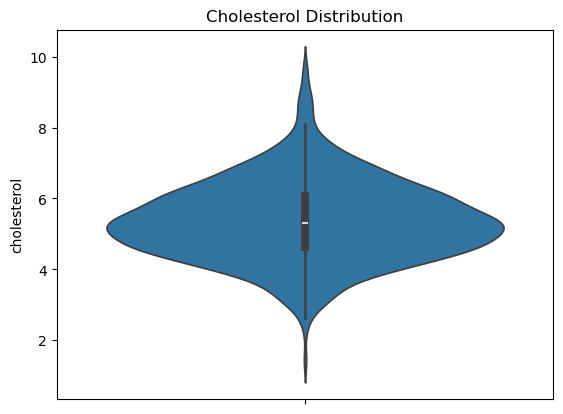

In [73]:
sns.violinplot(y='cholesterol',data=df)
plt.title('Cholesterol Distribution')
plt.show()

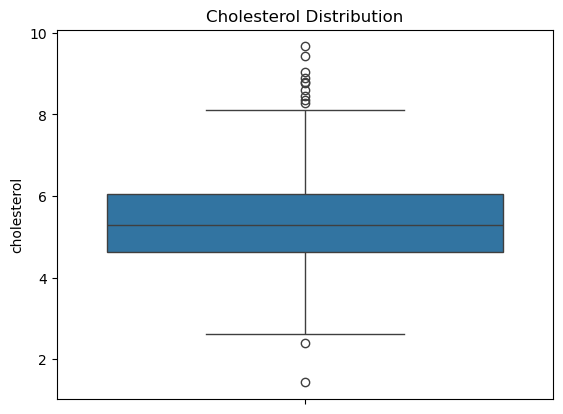

In [74]:
sns.boxplot(y='cholesterol',data=df)
plt.title('Cholesterol Distribution')
plt.show()

In [75]:
#The above violin and box plot shows there are not many outliers present and the values are not extreme as well.

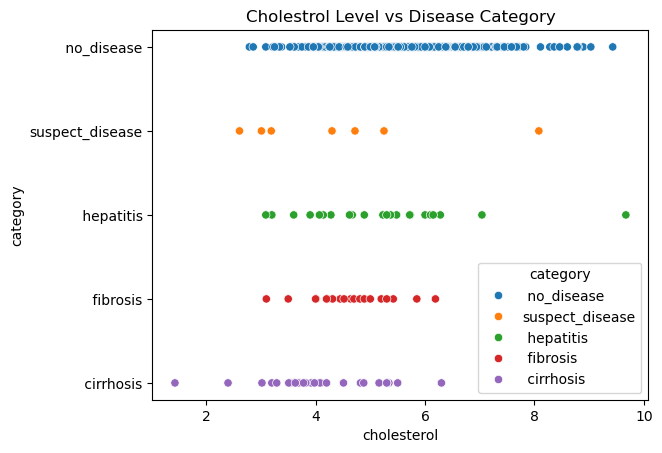

In [76]:
sns.scatterplot(x='cholesterol',y='category',hue='category',data=df)
plt.title('Cholestrol Level vs Disease Category')
plt.show()

In [77]:
#The above cholestrol comparison shows that people with normal level can also be prone to liver disease. Hence values cannot be treated as outliers
#as they are necessary in identifying the liver disease.

In [78]:
#STATS CALCULATION FOR CREATININE
Mean_creatinine = df['creatinine'].mean()
Median_creatinine = df['creatinine'].median()
Mode_creatinine = df['creatinine'].mode()
IQR_Q1 = df['creatinine'].quantile(0.25)
IQR_Q3 = df['creatinine'].quantile(0.75)
IQR_Range_creatinine = IQR_Q3 - IQR_Q1
print("Mean_creatinine:",Mean_creatinine)
print("Median_creatinine:",Median_creatinine)
print("Mode_creatinine:",Mode_creatinine)
print("IQR_Range_creatinine:",IQR_Range_creatinine)

Mean_creatinine: 81.28780487804877
Median_creatinine: 77.0
Mode_creatinine: 0    74.0
Name: creatinine, dtype: float64
IQR_Range_creatinine: 21.0


In [79]:
#The stats shows creatinine is slightly right skewed which can be seen by the mean value greater thant the median.

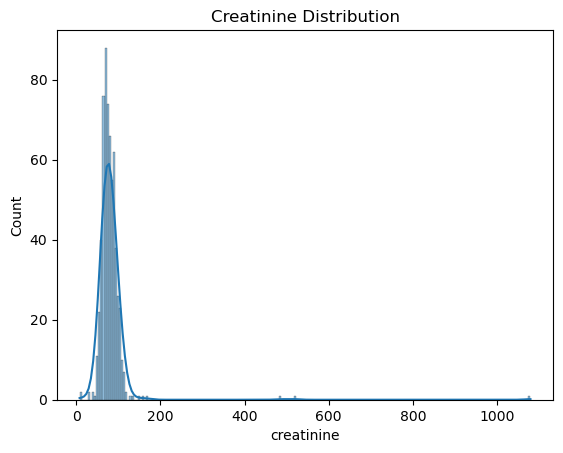

In [80]:
sns.histplot(x='creatinine',data=df,kde=True)
plt.title('Creatinine Distribution')
plt.show()

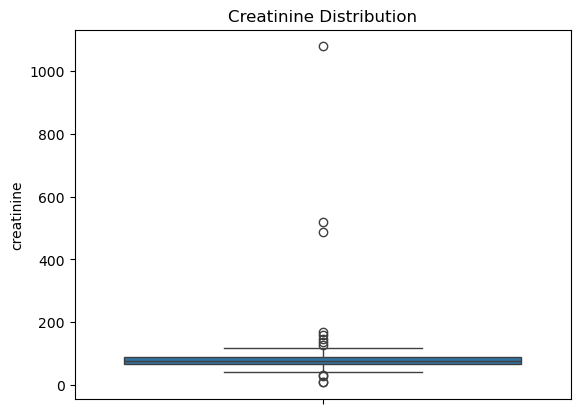

In [81]:
sns.boxplot(y='creatinine',data=df)
plt.title('Creatinine Distribution')
plt.show()

In [82]:
#The above plots show that the values are mostly distributed between 50 and 200 with some extremely high values.

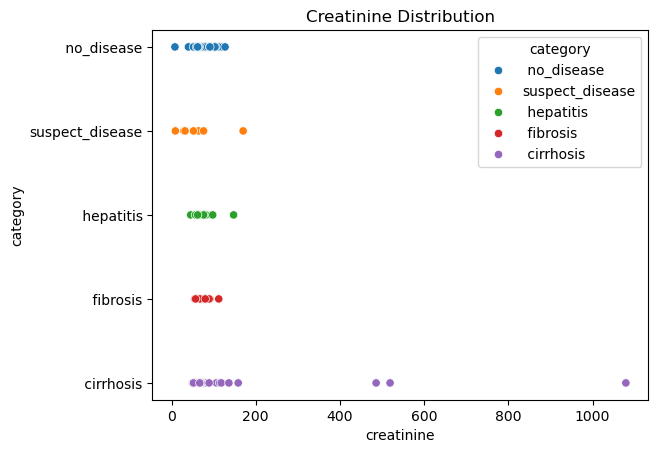

In [83]:
sns.scatterplot(x='creatinine',y='category',hue='category',data=df)
plt.title('Creatinine Distribution')
plt.show()

In [84]:
#Creatinine is a waste product by muscle metabolism and high levels often indicate liver failure.
#The above data shows that liver disease occurs in both people with normal as well as high creatinine levels.

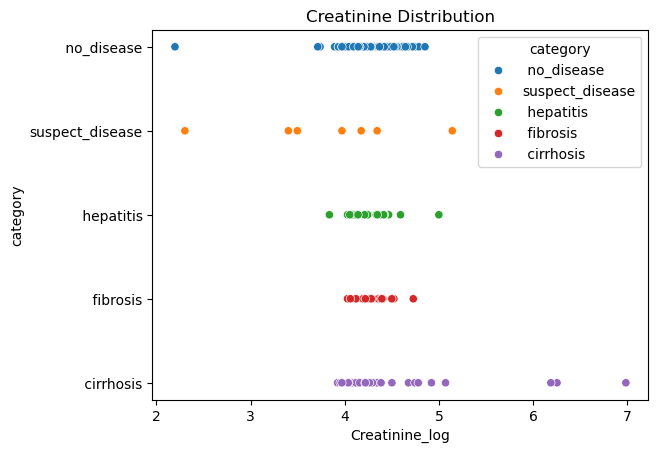

In [85]:
df['Creatinine_log'] = np.log1p(df['creatinine'])
sns.scatterplot(x='Creatinine_log',y='category',hue='category',data=df)
plt.title('Creatinine Distribution')
plt.show()

In [86]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

In [87]:
#STATS CALCULATION FOR GAMMA GLUTAMYL TRANSFERASE
Mean_gamma_glutamyl_transferase = df['gamma_glutamyl_transferase'].mean()
Median_gamma_glutamyl_transferase = df['gamma_glutamyl_transferase'].median()
Mode_gamma_glutamyl_transferase = df['gamma_glutamyl_transferase'].mode()
IQR_Q1 = df['gamma_glutamyl_transferase'].quantile(0.25)
IQR_Q3 = df['gamma_glutamyl_transferase'].quantile(0.75)
IQR_Range_gamma_glutamyl_transferase = IQR_Q3 - IQR_Q1
print("Mean_gamma_glutamyl_transferase:",Mean_gamma_glutamyl_transferase)
print("Median_gamma_glutamyl_transferase:",Median_gamma_glutamyl_transferase)
print("Mode_gamma_glutamyl_transferase:",Mode_gamma_glutamyl_transferase)
print("IQR_Range_gamma_glutamyl_transferase:",IQR_Range_gamma_glutamyl_transferase)

Mean_gamma_glutamyl_transferase: 39.53317073170732
Median_gamma_glutamyl_transferase: 23.3
Mode_gamma_glutamyl_transferase: 0    13.0
1    14.5
2    19.1
3    24.1
Name: gamma_glutamyl_transferase, dtype: float64
IQR_Range_gamma_glutamyl_transferase: 24.500000000000004


In [88]:
#The stats show Mean is greater than the median which indicates right skewed distribution.

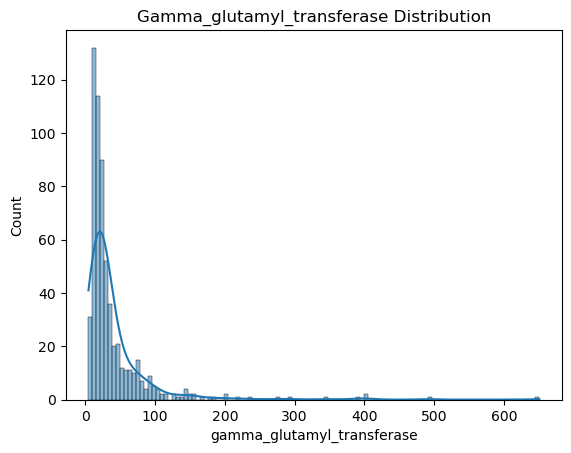

In [89]:
sns.histplot(x='gamma_glutamyl_transferase',data=df,kde=True)
plt.title('Gamma_glutamyl_transferase Distribution')
plt.show()

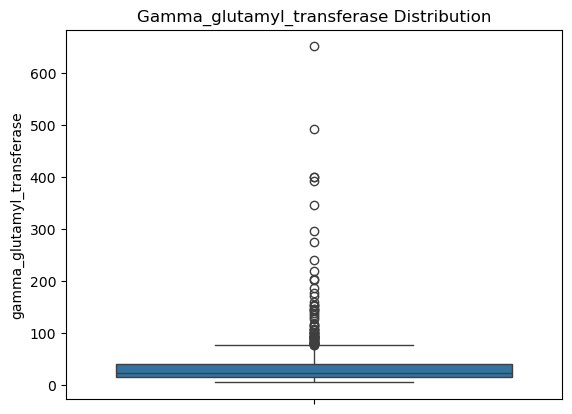

In [90]:
sns.boxplot(y='gamma_glutamyl_transferase',data=df)
plt.title('Gamma_glutamyl_transferase Distribution')
plt.show()

In [91]:
#The above plots show extreme high values which is an important indicator for liver disease. Hence these values cannot be considered as outliers.

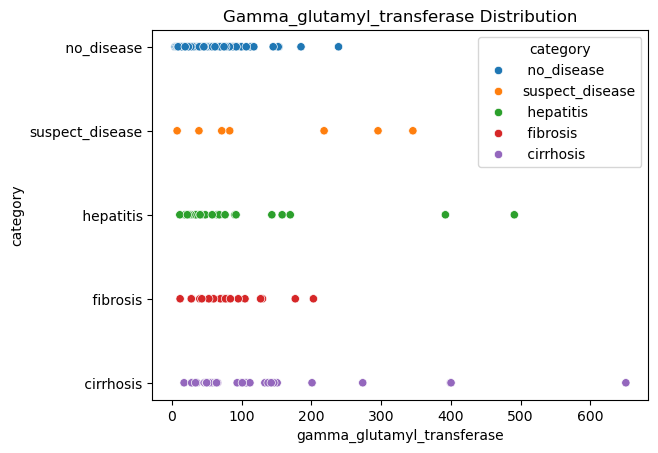

In [92]:
sns.scatterplot(x='gamma_glutamyl_transferase',y='category',hue='category',data=df)
plt.title('Gamma_glutamyl_transferase Distribution')
plt.show()

In [93]:
#The above comparison indicates that liver disease occurs even in people with normal levels of GGT.

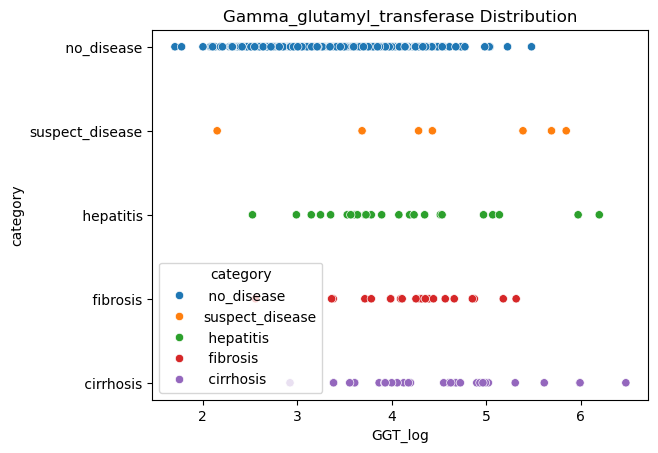

In [94]:
df['GGT_log'] = np.log1p(df['gamma_glutamyl_transferase'])
sns.scatterplot(x='GGT_log',y='category',hue='category',data=df)
plt.title('Gamma_glutamyl_transferase Distribution')
plt.show()

In [95]:
df["protein"] = pd.to_numeric(df["protein"], errors="coerce")


In [96]:
#STATS CALCULATION FOR GAMMA GLUTAMYL PROTEIN
Mean_protein = df['protein'].mean()
Median_protein = df['protein'].median()
Mode_protein = df['protein'].mode()
IQR_Q1 = df['protein'].quantile(0.25)
IQR_Q3 = df['protein'].quantile(0.75)
IQR_Range_protein = IQR_Q3 - IQR_Q1
print("Mean_protein:",Mean_protein)
print("Median_protein:",Median_protein)
print("Mode_protein:",Mode_protein)
print("IQR_Range_protein:",IQR_Range_protein)

Mean_protein: 72.0441368078176
Median_protein: 72.2
Mode_protein: 0    71.9
Name: protein, dtype: float64
IQR_Range_protein: 6.1000000000000085


In [97]:
df['protein']=df['protein'].fillna(df['protein'].median())

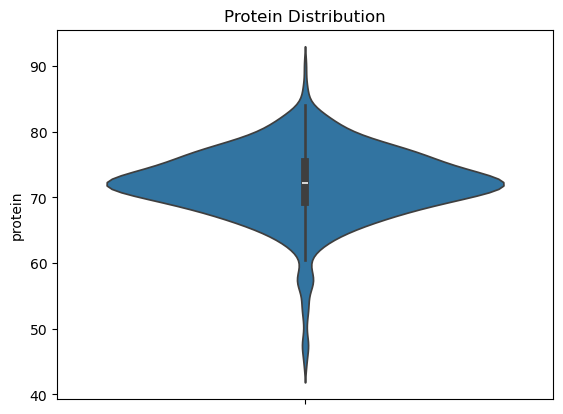

In [98]:
sns.violinplot(y='protein',data=df)
plt.title('Protein Distribution')
plt.show()

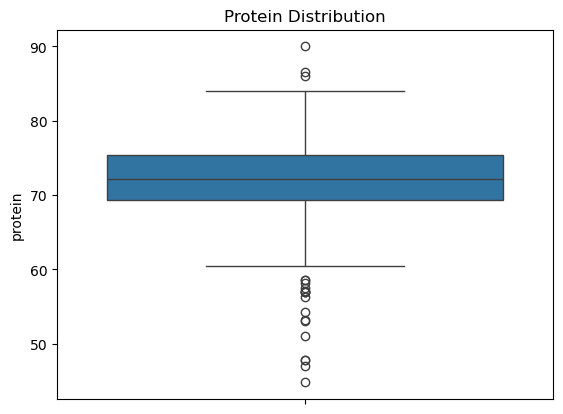

In [99]:
sns.boxplot(y='protein',data=df)
plt.title('Protein Distribution')
plt.show()

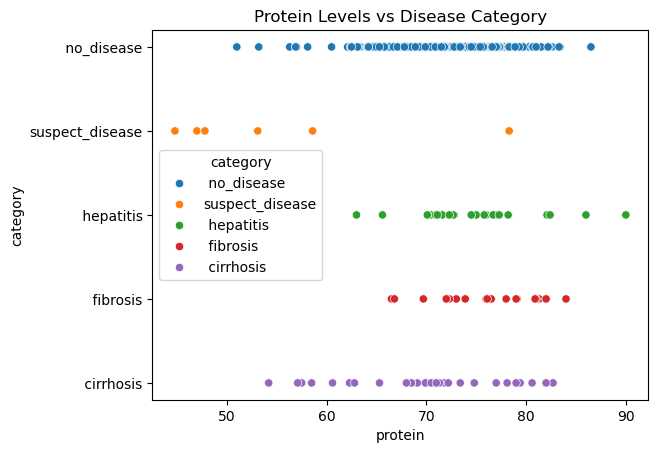

In [100]:
sns.scatterplot(x='protein',y='category',hue='category',data=df)
plt.title('Protein Levels vs Disease Category')
plt.show()

In [101]:
#DATA UNDERSTANDING
#This dataset contains demographic and biochemical parameters related to liver function. The target variable represents liver disease categories. 
#The objective of this EDA is to understand data quality, feature distributions, and clinically meaningful patterns that may assist in liver disease prediction.

In [102]:
#DATA HANDLING BASED ON THE DOMAIN
#Medical datasets often contain extreme values that represent severe disease states rather than noise. Therefore, statistical outlier removal techniques were not applied blindly. 
#Instead, laboratory values were interpreted using clinical reference ranges.

#-- Low albumin and cholinesterase values were retained as indicators of reduced liver synthetic function.
#-- Elevated liver enzymes (ALT, AST, ALP, GGT) were preserved as they reflect hepatocellular or cholestatic injury.
#-- High bilirubin and creatinine values were retained as they indicate severe liver and renal involvement.

In [103]:
#Feature Handling Summary

#| Feature | Low Values | High Values | Handling Strategy |
#| Albumin | Keep | Flag >55 g/L | Median impute high only |
#| ALT | Keep | Keep | Log transform |
#| AST | Keep | Keep | Log transform |
#| ALP | Keep | Keep | Log transform |
#| GGT | Keep | Keep | Log transform |
#| Bilirubin | Keep | Keep | Log transform |
#| Cholinesterase | Strong signal | Keep | Retain |
#| Creatinine | Keep | Keep | Log transform |
#| Cholesterol | Keep | Keep | Retain |
#| Total Protein | Keep | Keep | Retain |

In [104]:
#EDA Summary & Key Takeaways

# *No single laboratory parameter is sufficient to diagnose liver disease.
# *Albumin and cholinesterase are strong indicators of disease severity.
# *Enzyme elevations and bilirubin show overlap across disease categories.
# *Extreme laboratory values were clinically plausible and retained.
# *These findings highlight the need for a multivariate modeling approach.

In [105]:
#Implications for Modeling
#The EDA suggests that liver disease prediction requires a multivariate machine learning approach to capture complex 
#interactions among biochemical features rather than reliance on any single marker.

In [106]:
#Integrated EDA Narrative
#Taken together, albumin, cholinesterase, and bilirubin demonstrate patterns consistent with disease progression, 
#while enzyme markers capture injury-related variability. These findings reinforce that liver disease prediction is inherently multivariate and cannot rely on any single feature.
#The EDA prioritizes clinically grounded interpretation over rigid statistical assumptions. Observed distributions and relationships are described 
#cautiously, acknowledging biological variability while highlighting features that systematically reflect disease severity.

In [107]:
y=df['category']

In [108]:
df['albumin_high_outlier'] = df['albumin_high_outlier'].astype('float64')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   category                    615 non-null    object 
 1   age                         615 non-null    int64  
 2   sex                         615 non-null    object 
 3   albumin                     614 non-null    float64
 4   alkaline_phosphatase        615 non-null    float64
 5   alanine_aminotransferase    615 non-null    float64
 6   aspartate_aminotransferase  615 non-null    float64
 7   bilirubin                   615 non-null    float64
 8   cholinesterase              615 non-null    float64
 9   cholesterol                 615 non-null    float64
 10  creatinine                  615 non-null    float64
 11  gamma_glutamyl_transferase  615 non-null    float64
 12  protein                     615 non-null    float64
 13  albumin_high_outlier        615 non

In [110]:
df["sex"].value_counts(dropna=False)

sex
m    377
f    238
Name: count, dtype: int64

In [111]:
df["sex"] = (
    df["sex"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"nan": None})
)

In [112]:
#ENCODING CATEGORICAL COLUMNS BEFORE MODEL TRAINING
df['sex'] = df['sex'].map({'m':1,"f":0})

In [113]:
raw_data = ['sex','category','albumin','alkaline_phosphatase','alanine_aminotransferase','aspartate_aminotransferase','bilirubin','creatinine','gamma_glutamyl_transferase']

In [114]:
x=df.drop(columns=raw_data)
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   615 non-null    int64  
 1   cholinesterase        615 non-null    float64
 2   cholesterol           615 non-null    float64
 3   protein               615 non-null    float64
 4   albumin_high_outlier  615 non-null    float64
 5   alp_log               615 non-null    float64
 6   alt_log               615 non-null    float64
 7   asp_log               615 non-null    float64
 8   bilirubin_log         615 non-null    float64
 9   creatinine_log        615 non-null    float64
 10  GGT_log               615 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 53.0 KB


In [115]:
x.isna().sum()

age                     0
cholinesterase          0
cholesterol             0
protein                 0
albumin_high_outlier    0
alp_log                 0
alt_log                 0
asp_log                 0
bilirubin_log           0
creatinine_log          0
GGT_log                 0
dtype: int64

In [116]:
#LABEL ENCODING FOR MULTI CATEGORICAL COLUMN
y = df['category']
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
y_encoded = Le.fit_transform(y)

In [117]:
list(enumerate(Le.classes_))

[(0, ' cirrhosis'),
 (1, ' fibrosis'),
 (2, ' hepatitis'),
 (3, ' no_disease'),
 (4, 'suspect_disease')]

In [118]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded)

In [119]:
#FIRST MODEL - LOGISTIC REGRESSION
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="lbfgs"
    ))
])
logreg_pipeline.fit(x_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000))])

In [120]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = logreg_pipeline.predict(x_test)
print(classification_report(y_test, y_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.50      0.25      0.33         4
           2       0.67      0.40      0.50         5
           3       0.96      1.00      0.98       107
           4       0.00      0.00      0.00         1

    accuracy                           0.93       123
   macro avg       0.59      0.50      0.53       123
weighted avg       0.92      0.93      0.92       123



In [121]:
#The above result shows overall accuracy is high due to models good accuracy in predicting 3rd class but it is weak in predicting minority classes 
#especially 4 th class since there is not much sample available for that class.
#INTERPRETATION BASED ON THE ABOVE METRICS
#Although the model achieves high accuracy, macro F1-score reveals uneven performance across disease categories. 
#This is primarily due to class imbalance, where the majority class dominates predictions. Minority classes, 
#especially rare conditions, remain challenging to predict reliably.

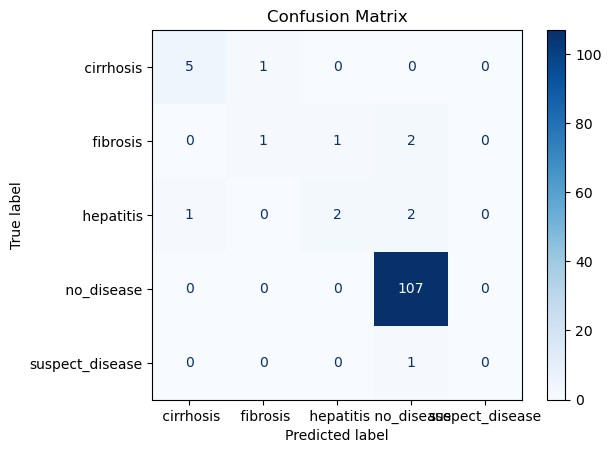

In [122]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=Le.classes_  
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [123]:
#SECOND MODEL - DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report
Dt = DecisionTreeClassifier(random_state=42,max_depth=5)
Dt.fit(x_train,y_train)
y_pred_dt = Dt.predict(x_test)
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.33      0.50      0.40         4
           2       0.50      0.20      0.29         5
           3       0.97      0.97      0.97       107
           4       0.00      0.00      0.00         1

    accuracy                           0.90       123
   macro avg       0.48      0.47      0.45       123
weighted avg       0.90      0.90      0.90       123



In [124]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced" 
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.33      0.25      0.29         4
           2       0.00      0.00      0.00         5
           3       0.95      1.00      0.97       107
           4       0.00      0.00      0.00         1

    accuracy                           0.91       123
   macro avg       0.39      0.38      0.39       123
weighted avg       0.87      0.91      0.89       123



In [125]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
svm_pipeline = Pipeline([("imputer",SimpleImputer(strategy="median")),
                         ("scaler",StandardScaler()),
                         ("Model",SVC(kernel="rbf",
                                    C=1.0,
                                      gamma='scale',
                                      class_weight="balanced",
                                      probability=True,
                                      random_state=42
                                     ))
                        ])
svm_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('Model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [126]:
y_pred_svm = svm_pipeline.predict(x_test)

from sklearn.metrics import classification_report, confusion_matrix

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print(confusion_matrix(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.50      0.25      0.33         4
           2       0.60      0.60      0.60         5
           3       0.98      1.00      0.99       107
           4       0.00      0.00      0.00         1

    accuracy                           0.94       123
   macro avg       0.56      0.54      0.54       123
weighted avg       0.93      0.94      0.93       123

[[  5   1   0   0   0]
 [  1   1   2   0   0]
 [  1   0   3   1   0]
 [  0   0   0 107   0]
 [  0   0   0   1   0]]


In [127]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=150,
                                            random_state=42))])

In [128]:
y_pred_gb = gb_pipeline.predict(x_test)

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.50      0.25      0.33         4
           2       0.67      0.40      0.50         5
           3       0.96      1.00      0.98       107
           4       0.00      0.00      0.00         1

    accuracy                           0.93       123
   macro avg       0.57      0.50      0.52       123
weighted avg       0.92      0.93      0.92       123

[[  5   1   0   0   0]
 [  1   1   1   1   0]
 [  1   0   2   2   0]
 [  0   0   0 107   0]
 [  0   0   0   1   0]]


In [129]:
#MODEL COMPARISON
from sklearn.metrics import accuracy_score,f1_score
import pandas as pd
Model_comparison = pd.DataFrame({"Model":['Logistic Regression','Decision Tree','Random Forest','SVM','Gradient Boosting'],
                                 "Accuracy":[accuracy_score(y_test,y_pred),
                                            accuracy_score(y_test,y_pred_dt),
                                            accuracy_score(y_test,y_pred_rf),
                                            accuracy_score(y_test,y_pred_svm),
                                            accuracy_score(y_test,y_pred_gb)],
                                 "Macro F1":[f1_score(y_test,y_pred,average="macro"),
                                            f1_score(y_test,y_pred_dt,average="macro"),
                                            f1_score(y_test,y_pred_rf,average="macro"),
                                            f1_score(y_test,y_pred_svm,average="macro"),
                                            f1_score(y_test,y_pred_svm,average="macro")]
                                })
Model_comparison

,Model,Accuracy,Macro F1
0,Logistic Regression,0.934959,0.528767
1,Decision Tree,0.902439,0.454612
2,Random Forest,0.910569,0.385022
3,SVM,0.943089,0.538661
4,Gradient Boosting,0.934959,0.538661


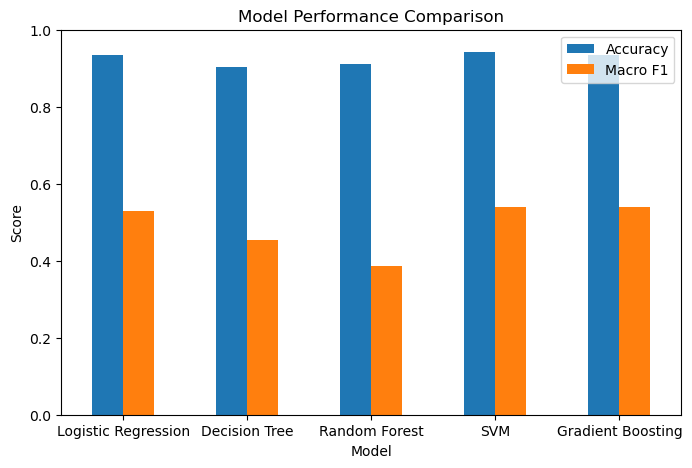

In [130]:
#MODEL COMPARISON VISUALIZATION
Model_comparison.set_index("Model").plot(kind='bar',ylim=(0,1),figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [131]:
#KEY INSIGHTS
#We evaluated linear, non-linear, and ensemble models. While all models achieved high accuracy due to class imbalance, macro F1-score revealed 
#meaningful differences. SVM achieved the highest macro F1-score, indicating more balanced performance across disease categories. 
#Therefore, SVM was selected as the final model.

In [132]:
#SVM MODEL DEPLOYMENT IN STREAMLIT USING FAST API
import joblib
joblib.dump(svm_pipeline,"Liver_Prediction_SVM.pkl")

['Liver_Prediction_SVM.pkl']

In [133]:
!python --version

Python 3.13.5


In [134]:
import sklearn
sklearn.__version__

'1.6.1'